# CIFAR-10 -- Final Training with Data Augmentation

This notebook builds on the architecture identified in Notebook 2 through a systematic ablation study.
We now take the optimized model:

> **3 blocks — 32‑64‑128 filters — LeakyReLU — Dropout (0.2) — AdamW (wd=0.001)**

and evaluate how far we can push its performance using **data augmentation** and **mixed‑precision training**.

The goal of this notebook is not to explore new architectural choices, but to:

- apply realistic data augmentation to improve generalization
- train the final model end‑to‑end
- evaluate its performance on the test set
- analyze failure cases through a confusion matrix and misclassified examples

This notebook represents the **final training phase** of the project.

## 1 - Librairies

In [ ]:
import tensorflow as tf
import tensorflow_datasets as tfds
from tensorflow.keras import mixed_precision
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import random
import os
from sklearn.metrics import confusion_matrix
import itertools

SEED=42

tf.random.set_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)
os.environ['PYTHONHASHSEED'] = str(SEED)

## 2 - Data Loading & Preprocessing

We reuse the same preprocessing pipeline as in previous notebooks to ensure consistency:

- resizing to 32×32
- rescaling pixel values
- batching and prefetching

### 2.1 - Load Data :

In [ ]:
(data_train, data_test, data_val), infos = tfds.load(
    'cifar10',
    split=[
        'train[:48000]',              # 80%
        'train[48000:]+test[:4000]',  # 10%
        'test[4000:]'                 # 10%
    ],
    shuffle_files=True,
    as_supervised=True,
    with_info=True
)

print("Dataset loaded successfully.")

Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Extraction completed...: 0 file [00:00, ? file/s]

Generating splits...:   0%|          | 0/2 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/cifar10/incomplete.HBRPOI_3.0.2/cifar10-train.tfrecord*...:   0%|         …

Generating test examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/cifar10/incomplete.HBRPOI_3.0.2/cifar10-test.tfrecord*...:   0%|          …

Dataset cifar10 downloaded and prepared to /root/tensorflow_datasets/cifar10/3.0.2. Subsequent calls will reuse this data.
Dataset loaded successfully.
Train batches: 48000
Validation batches: 6000
Test batches: 6000


### 2.2 - Preprocessing Pipeline :

In [ ]:
# Preprocessing Layer -> Resize + Rescale
resize_rescale = tf.keras.Sequential([
    tf.keras.layers.Resizing(32, 32),
    tf.keras.layers.Rescaling(1.0 / 255)
])

# Preprocessing Functions
def preprocess(dataset):

    dataset = dataset.shuffle(buffer_size=1000,seed=SEED)

    # Resize + rescale
    dataset = dataset.map(
        lambda x, y: (resize_rescale(x), y),
        num_parallel_calls=tf.data.AUTOTUNE
    )

    # Batch + prefetch
    dataset = dataset.batch(64)
    return dataset.prefetch(tf.data.AUTOTUNE)

# Create Preprocessed Datasets
batch_train = preprocess(data_train)
batch_val   = preprocess(data_val)
batch_test  = preprocess(data_test)

## 3 - Data Augmentation

Data augmentation is essential for improving generalization on CIFAR‑10.
Since the dataset is relatively small and contains natural images, we apply light but realistic transformations:

- random flips
- random rotations
- random translations
- slight color jitter

The goal is to expose the model to plausible variations without distorting the semantic content.

We visualize a batch of augmented images to verify that the transformations remain realistic.

### 3.1 - Data Augmentation Function

In [ ]:
# Data Augmentation Layer
def get_data_augmentation(strength=0.1):
    return tf.keras.Sequential([
        tf.keras.layers.RandomFlip("horizontal"),
        tf.keras.layers.RandomRotation(strength),
        tf.keras.layers.RandomTranslation(strength, strength),
        tf.keras.layers.RandomZoom(strength),
    ], name=f"data_aug_{strength}")

### 3.2 - Visualization :

We visualize three random samples from the training set under two augmentation strengths (0.1 and 0.2).  
This helps verify that the transformations remain realistic and do not distort the semantic content of the images.

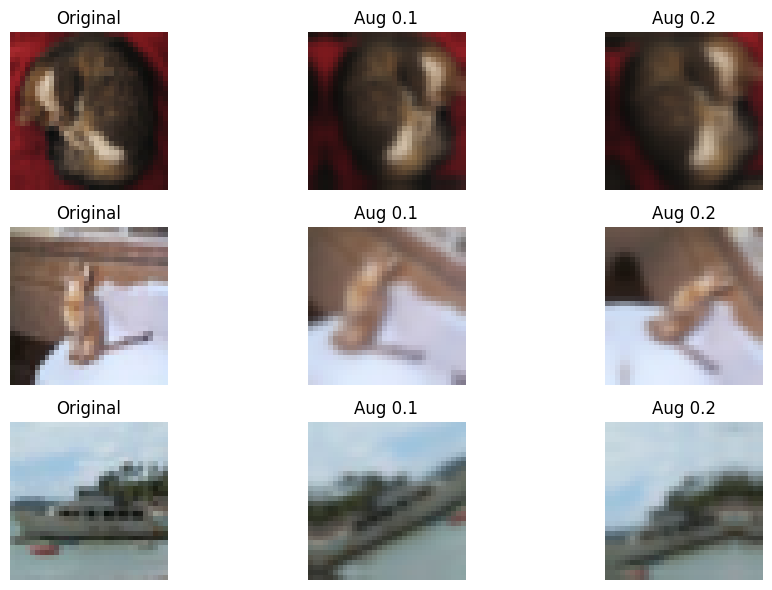

In [ ]:
# Take 3 random images from the training set
for images, labels in batch_train.take(1):
    idx = tf.random.shuffle(tf.range(len(images)))[:3]
    sample_images = tf.gather(images, idx)
    break

# Create augmentation layers
aug_01 = get_data_augmentation(0.1)
aug_02 = get_data_augmentation(0.2)

# Apply augmentations
augmented_01 = aug_01(sample_images)
augmented_02 = aug_02(sample_images)

# Plot 3x3 grid
plt.figure(figsize=(10, 6))

for i in range(3):
    # Original
    ax = plt.subplot(3, 3, i*3 + 1)
    plt.imshow(sample_images[i].numpy())
    plt.title("Original")
    plt.axis("off")

    # Aug 0.1
    ax = plt.subplot(3, 3, i*3 + 2)
    plt.imshow(augmented_01[i].numpy())
    plt.title("Aug 0.1")
    plt.axis("off")

    # Aug 0.2
    ax = plt.subplot(3, 3, i*3 + 3)
    plt.imshow(augmented_02[i].numpy())
    plt.title("Aug 0.2")
    plt.axis("off")

plt.tight_layout()
plt.show()

## 4 - Model Setup

We now prepare the final training environment:

- Mixed precision to accelerate training on GPU and reduces memory usage, without affecting model accuracy.
- Callbacks (EarlyStopping, ReduceLROnPlateau, ModelCheckpoint)
- Final architecture from Notebook 2
- AdamW optimizer with weight decay = 0.001

No architectural changes are introduced here — the model is fixed.
The only variable we study is the effect of data augmentation.

### 4.1 - Callbacks

In [ ]:
def get_callbacks(name):
    return [
        tf.keras.callbacks.EarlyStopping(
            monitor="val_loss",
            patience=5,
            restore_best_weights=True
        ),
        tf.keras.callbacks.ReduceLROnPlateau(
            monitor="val_loss",
            factor=0.2,
            patience=2,
            min_lr=1e-7
        ),
        tf.keras.callbacks.ModelCheckpoint(
            filepath=f"checkpoints/{name}.weights.h5",
            monitor="val_accuracy",
            save_best_only=True,
            save_weights_only=True,
            mode="max"
        )
    ]

### 4.2 - Creation Function

In [ ]:
def create_cnn(
    input_shape=(32, 32, 3),
    blocks=[32],                 # e.g. [32], [32,64], [32,64,128]
    dropout_block=0.0,           # dropout after each block
    activation='relu',
    optimizer='adamw',
    weight_decay=0.004,          # Default weight_decay
    lr=0.001,
    padding='same',
    seed=SEED,
    use_augmentation=False,
    aug_strength=0.1
):
    tf.random.set_seed(seed)

    model = tf.keras.Sequential()
    model.add(tf.keras.layers.Input(shape=input_shape))

    # Optional Data Augmentation before CNN
    if use_augmentation:
        model.add(get_data_augmentation(aug_strength))

    # Convolutional blocks
    for filters in blocks:
        model.add(tf.keras.layers.Conv2D(filters, 3, activation=activation, padding=padding))
        model.add(tf.keras.layers.BatchNormalization())
        model.add(tf.keras.layers.Conv2D(filters, 3, activation=activation, padding=padding))
        model.add(tf.keras.layers.BatchNormalization())
        model.add(tf.keras.layers.MaxPool2D())
        if dropout_block > 0:
            model.add(tf.keras.layers.Dropout(dropout_block))

    # Global pooling
    model.add(tf.keras.layers.GlobalAveragePooling2D())

    # Output layer
    model.add(tf.keras.layers.Dense(10))
    model.add(tf.keras.layers.Activation('softmax', dtype=tf.float32))

    # Optimizer
    if optimizer == 'adamw':
        opt = tf.keras.optimizers.AdamW(weight_decay=weight_decay)
    elif optimizer == 'adam':
        opt = tf.keras.optimizers.Adam()

    model.compile(
        loss=tf.keras.losses.SparseCategoricalCrossentropy(),
        optimizer=opt,
        metrics=['accuracy']
    )

    return model

### 4.3 - Mixed Precision

Mixed precision significantly reduces memory usage and speeds up training on modern GPUs, without affecting model accuracy.

In [ ]:
# Enable mixed precision (float16 + float32)
mixed_precision.set_global_policy('mixed_float16')
print("Mixed precision policy:", mixed_precision.global_policy())

Mixed precision policy: <DTypePolicy "mixed_float16">


## 5 - Final Experiment : Training with Data Augmentation

We train the final model with and without data augmentation to quantify its impact.
This experiment answers a simple but important question:

> “How much does data augmentation improve generalization on CIFAR‑10 for our optimized architecture?”

We compare:

- training curves
- validation curves
- final test accuracy

This is the last performance‑oriented experiment of the project.

### 5.1 - No data augmentation

Here we train the model without data augmentation.
We keep epochs = 30 because it should converge relatively fast.

In [ ]:
model_0 = create_cnn(
    blocks=[32, 64,128],
    dropout_block=0.2,
    use_augmentation=False,
    activation='leaky_relu',
    optimizer='adamw',
    weight_decay=0.001)

history_0 = model_0.fit(
    batch_train,
    validation_data=batch_val,
    epochs=30,
    verbose=2,
    callbacks=get_callbacks('model_0')
)

Epoch 1/30
750/750 - 34s - 45ms/step - accuracy: 0.5382 - loss: 1.2908 - val_accuracy: 0.6372 - val_loss: 1.0299 - learning_rate: 1.0000e-03
Epoch 2/30
750/750 - 7s - 9ms/step - accuracy: 0.6747 - loss: 0.9253 - val_accuracy: 0.6607 - val_loss: 0.9662 - learning_rate: 1.0000e-03
Epoch 3/30
750/750 - 9s - 12ms/step - accuracy: 0.7259 - loss: 0.7868 - val_accuracy: 0.6340 - val_loss: 1.0431 - learning_rate: 1.0000e-03
Epoch 4/30
750/750 - 8s - 11ms/step - accuracy: 0.7588 - loss: 0.6961 - val_accuracy: 0.7438 - val_loss: 0.7212 - learning_rate: 1.0000e-03
Epoch 5/30
750/750 - 6s - 8ms/step - accuracy: 0.7797 - loss: 0.6352 - val_accuracy: 0.7647 - val_loss: 0.6975 - learning_rate: 1.0000e-03
Epoch 6/30
750/750 - 10s - 14ms/step - accuracy: 0.7976 - loss: 0.5856 - val_accuracy: 0.7683 - val_loss: 0.6897 - learning_rate: 1.0000e-03
Epoch 7/30
750/750 - 8s - 10ms/step - accuracy: 0.8103 - loss: 0.5515 - val_accuracy: 0.7465 - val_loss: 0.7517 - learning_rate: 1.0000e-03
Epoch 8/30
750/750 -

### 5.2 - Data Augmentation (strength = 0.1)

Data augmentation needs much more epochs because it keep seeing different images due to augmentation. We increase the number of epochs to 100, but training will stop earlier thanks to our callbacks.

In [ ]:
model_1 = create_cnn(
    blocks=[32, 64,128],
    dropout_block=0.2,
    use_augmentation=True,
    aug_strength=0.1,
    activation='leaky_relu',
    optimizer='adamw',
    weight_decay=0.001)

history_1 = model_1.fit(
    batch_train,
    validation_data=batch_val,
    epochs=100,
    verbose=2,
    callbacks=get_callbacks('model_1')
)

Epoch 1/100
750/750 - 36s - 48ms/step - accuracy: 0.4415 - loss: 1.5510 - val_accuracy: 0.4410 - val_loss: 1.9532 - learning_rate: 1.0000e-03
Epoch 2/100
750/750 - 22s - 30ms/step - accuracy: 0.5422 - loss: 1.2789 - val_accuracy: 0.4077 - val_loss: 2.2969 - learning_rate: 1.0000e-03
Epoch 3/100
750/750 - 36s - 48ms/step - accuracy: 0.5890 - loss: 1.1546 - val_accuracy: 0.5798 - val_loss: 1.3631 - learning_rate: 1.0000e-03
Epoch 4/100
750/750 - 20s - 27ms/step - accuracy: 0.6224 - loss: 1.0723 - val_accuracy: 0.5845 - val_loss: 1.3269 - learning_rate: 1.0000e-03
Epoch 5/100
750/750 - 20s - 27ms/step - accuracy: 0.6472 - loss: 1.0033 - val_accuracy: 0.6383 - val_loss: 1.1277 - learning_rate: 1.0000e-03
Epoch 6/100
750/750 - 17s - 22ms/step - accuracy: 0.6662 - loss: 0.9535 - val_accuracy: 0.5852 - val_loss: 1.4795 - learning_rate: 1.0000e-03
Epoch 7/100
750/750 - 18s - 25ms/step - accuracy: 0.6768 - loss: 0.9191 - val_accuracy: 0.6768 - val_loss: 1.0216 - learning_rate: 1.0000e-03
Epoch 

### 5.3 - Data Augmentation (strength = 0.2)

In [ ]:
model_2 = create_cnn(
    blocks=[32, 64,128],
    dropout_block=0.2,
    use_augmentation=True,
    aug_strength=0.2,
    activation='leaky_relu',
    optimizer='adamw',
    weight_decay=0.001)

history_2 = model_2.fit(
    batch_train,
    validation_data=batch_val,
    epochs=100,
    verbose=2,
    callbacks=get_callbacks('model_2')
)

Epoch 1/100
750/750 - 24s - 32ms/step - accuracy: 0.3447 - loss: 1.8117 - val_accuracy: 0.2687 - val_loss: 2.8704 - learning_rate: 1.0000e-03
Epoch 2/100
750/750 - 17s - 23ms/step - accuracy: 0.4201 - loss: 1.6010 - val_accuracy: 0.4628 - val_loss: 1.6246 - learning_rate: 1.0000e-03
Epoch 3/100
750/750 - 17s - 23ms/step - accuracy: 0.4668 - loss: 1.4765 - val_accuracy: 0.4858 - val_loss: 1.5251 - learning_rate: 1.0000e-03
Epoch 4/100
750/750 - 17s - 23ms/step - accuracy: 0.5047 - loss: 1.3816 - val_accuracy: 0.5363 - val_loss: 1.3779 - learning_rate: 1.0000e-03
Epoch 5/100
750/750 - 21s - 28ms/step - accuracy: 0.5317 - loss: 1.3165 - val_accuracy: 0.4933 - val_loss: 1.5264 - learning_rate: 1.0000e-03
Epoch 6/100
750/750 - 17s - 22ms/step - accuracy: 0.5527 - loss: 1.2628 - val_accuracy: 0.5292 - val_loss: 1.4470 - learning_rate: 1.0000e-03
Epoch 7/100
750/750 - 18s - 23ms/step - accuracy: 0.5898 - loss: 1.1625 - val_accuracy: 0.6292 - val_loss: 1.0580 - learning_rate: 2.0000e-04
Epoch 

## 6 - Conclusion

In [ ]:
print("Accuracy without data augmentation:", model_0.evaluate(batch_test)[1])
print("Accuracy with data augmentation (0.1):", model_1.evaluate(batch_test)[1])
print("Accuracy with data augmentation (0.2):", model_2.evaluate(batch_test)[1])

94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.8743 - loss: 0.3759
Accuracy without data augmentation: 0.875
94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.7913 - loss: 0.6127
Accuracy with data augmentation (0.1): 0.7904999852180481
94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.6827 - loss: 0.9066
Accuracy with data augmentation (0.2): 0.6806666851043701


<Axes: title={'center': 'Loss: No data augmentation vs 0.1 aug_strength vs 0.2 aug_strength'}>

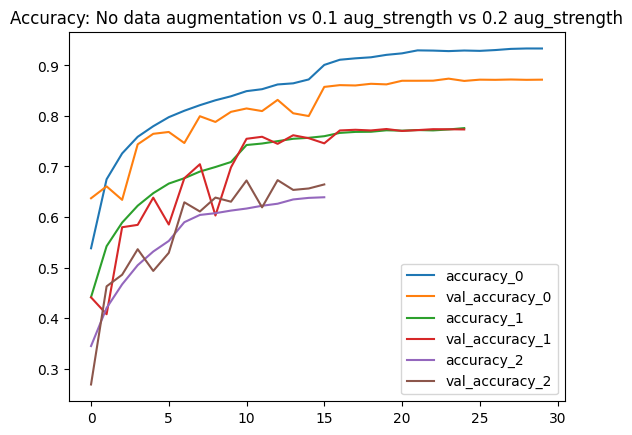

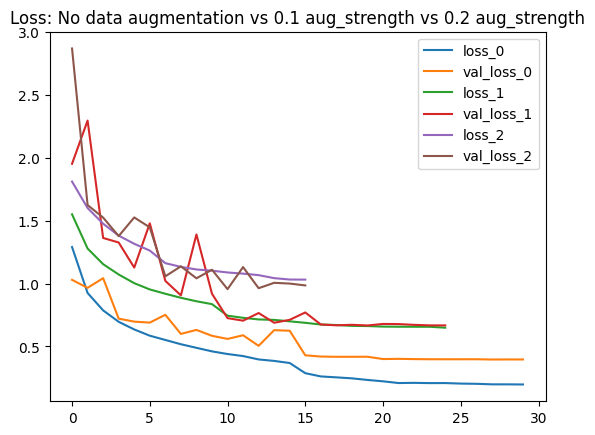

In [ ]:
# Plot curves :

df_0 = pd.DataFrame(history_0.history).drop(columns=['learning_rate'])
df_0.columns = ['accuracy_0', 'loss_0', 'val_accuracy_0', 'val_loss_0']
df_0_acc = df_0[['accuracy_0','val_accuracy_0']]
df_0_loss = df_0[['loss_0','val_loss_0']]

df_1 = pd.DataFrame(history_1.history).drop(columns=['learning_rate'])
df_1.columns = ['accuracy_1', 'loss_1', 'val_accuracy_1', 'val_loss_1']
df_1_acc = df_1[['accuracy_1','val_accuracy_1']]
df_1_loss = df_1[['loss_1','val_loss_1']]

df_2 = pd.DataFrame(history_2.history).drop(columns=['learning_rate'])
df_2.columns = ['accuracy_2', 'loss_2', 'val_accuracy_2', 'val_loss_2']
df_2_acc = df_2[['accuracy_2','val_accuracy_2']]
df_2_loss = df_2[['loss_2','val_loss_2']]

pd.concat([df_0_acc,
           df_1_acc,
           df_2_acc], axis=1
          ).plot(title="Accuracy: No data augmentation vs 0.1 aug_strength vs 0.2 aug_strength")

pd.concat([df_0_loss,
           df_1_loss,
           df_2_loss], axis=1
          ).plot(title="Loss: No data augmentation vs 0.1 aug_strength vs 0.2 aug_strength")

### Conclusion — Data Augmentation

We evaluated several data augmentation strengths (0.1 and 0.2) using the final architecture identified in Notebook 2.  
Surprisingly, augmentation consistently degraded validation accuracy and triggered early stopping much earlier than the baseline.  
This indicates that, in our setup, the combination of dropout, weight decay, and augmentation introduces too much regularization, preventing the model from fitting the data properly. We could try a less aggressive augmentation (0.05) seeing that 0.2 is even worst than 0.1.

Since augmentation does not improve generalization and even harms performance, we retain the **non‑augmented training** as our final configuration.

## 7 - Confusion Matrix

To better understand the model’s behavior, we compute a confusion matrix on the test set. This reveals which classes are most frequently confused and highlights potential weaknesses in the learned representation.

In [ ]:
# https://stackoverflow.com/questions/64622210/how-to-extract-classes-from-prefetched-dataset-in-tensorflow-for-confusion-matri

y_pred = []  # store predicted labels
y_true = []  # store true labels

# iterate over the dataset
for image_batch, label_batch in batch_test:   # use dataset.unbatch() with repeat
   # append true labels
   y_true.append(label_batch)
   # compute predictions
   preds = model_0.predict(image_batch,verbose=0)
   # append predicted labels
   y_pred.append(np.argmax(preds, axis = 1))

# convert the true and predicted labels into tensors
correct_labels = tf.concat([item for item in y_true], axis = 0)
predicted_labels = tf.concat([item for item in y_pred], axis = 0)

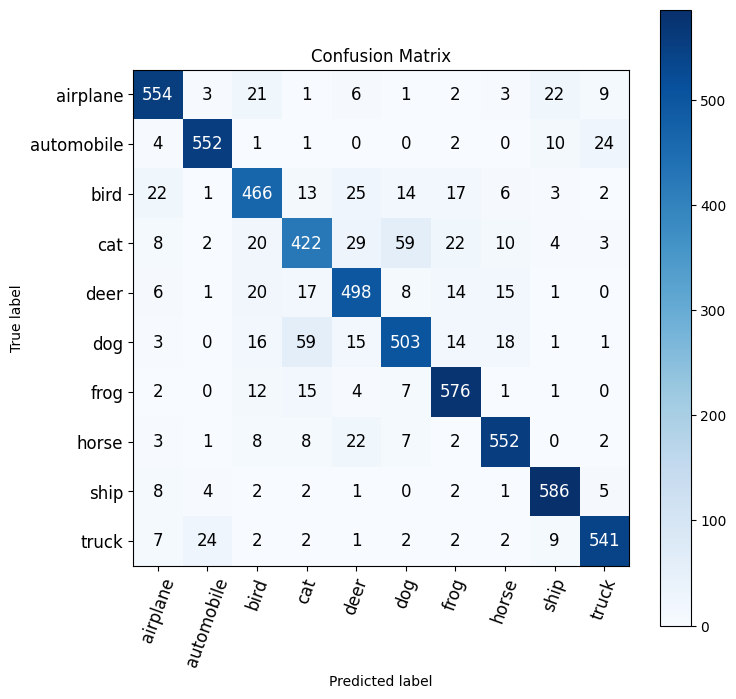

In [ ]:
# https://github.com/mrdbourke/tensorflow-deep-learning/blob/main/06_transfer_learning_in_tensorflow_part_3_scaling_up.ipynb

n_classes=len(class_names)

cm = confusion_matrix(correct_labels, predicted_labels)

# Plot the figure and make it pretty
fig, ax = plt.subplots(figsize=(8,8))
cax = ax.matshow(cm, cmap=plt.cm.Blues) # colors will represent how 'correct' a class is, darker == better
fig.colorbar(cax)

# Label the axes
ax.set(title="Confusion Matrix",
        xlabel="Predicted label",
        ylabel="True label",
        xticks=np.arange(n_classes), # create enough axis slots for each class
        yticks=np.arange(n_classes),
        xticklabels=class_names,
        yticklabels=class_names)

# Make x-axis labels appear on bottom
ax.xaxis.set_label_position("bottom")
ax.xaxis.tick_bottom()

### Added: Rotate xticks for readability & increase font size (required due to such a large confusion matrix)
plt.xticks(rotation=70, fontsize=12)
plt.yticks(fontsize=12)

# Set the threshold for different colors
threshold = (cm.max() + cm.min()) / 2.

# Plot the text on each cell
for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
  plt.text(j, i, f"{cm[i, j]}",
          ha="center",
          va='center',
          color="white" if cm[i, j] > threshold else "black",
          size=12)

## 8 - Examples of Misclassifications

To complement the confusion matrix, we inspect a few misclassified samples.  
This qualitative analysis helps understand whether errors come from ambiguous images, class similarity, or model limitations.

This closes the project with a human‑interpretable evaluation of the model’s errors.


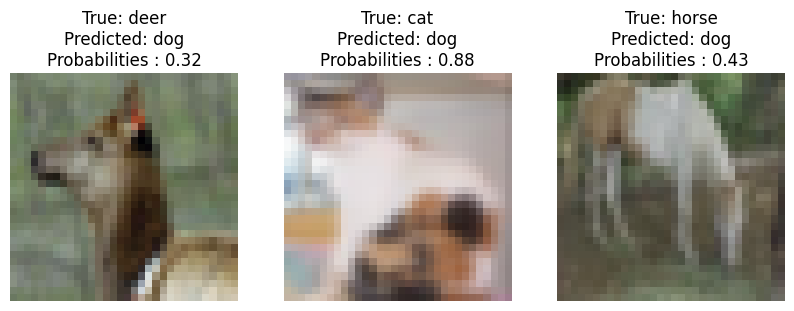

In [ ]:
# Get the indices of the first 3 wrong classifications
wrong_indices = []
images_to_show = []
labels_to_show = []
preds_to_show = []
prob = []
current_index = 0

for image_batch, label_batch in batch_test:
    preds = model_0.predict(image_batch, verbose=0)
    predicted_labels_batch = np.argmax(preds, axis=1)
    true_labels_batch = label_batch.numpy()

    for i in range(tf.shape(image_batch)[0].numpy()):
        if predicted_labels_batch[i] != true_labels_batch[i]:
            if len(wrong_indices) < 3:
                wrong_indices.append(current_index)
                images_to_show.append(image_batch[i].numpy())
                labels_to_show.append(true_labels_batch[i])
                preds_to_show.append(predicted_labels_batch[i])
                prob.append(np.round(tf.cast(np.max(preds[i]),"float64"),2))
        current_index += 1
        if len(wrong_indices) == 3:
            break
    if len(wrong_indices) == 3:
        break

# Display the images with their true and predicted labels
plt.figure(figsize=(10, 10))
for i in range(len(images_to_show)):
    plt.subplot(1, len(images_to_show), i + 1)
    plt.imshow(images_to_show[i])
    true_label = class_names[labels_to_show[i]]
    predicted_label = class_names[preds_to_show[i]]
    plt.title(f"True: {true_label}\nPredicted: {predicted_label}\nProbabilities : {prob[i]}")
    plt.axis('off')
plt.show()

## Final Project Conclusion

Across three notebooks, we progressively built, analyzed, and optimized a CNN for CIFAR‑10.  
Notebook 1 established a baseline, Notebook 2 performed a systematic ablation study to identify the best architecture and regularization strategy, and Notebook 3 evaluated the impact of data augmentation and finalized the training.

The best configuration is:

**3 convolutional blocks — 32‑64‑128 filters — LeakyReLU — Dropout(0.2) — AdamW (wd=0.001)**

Data augmentation did not improve performance in our setup, likely due to the already strong regularization.  
The final model achieves solid accuracy and shows consistent behavior across classes, with remaining errors concentrated on visually ambiguous samples.

This concludes the project with a robust, well‑justified architecture and a clear understanding of its strengths and limitations.


## Limitations & Future Work

- The model remains relatively shallow compared to modern architectures such as ResNet.
- Stronger augmentation strategies (Cutout, Mixup, CutMix) were not explored.
- Hyperparameter tuning (learning rate, batch size) was limited to reasonable defaults.
- Transfer learning or pretrained models could further improve performance.

These directions could be explored in future iterations of the project.
